# TrustCV on PhysioNet 2019 Sepsis: a real clinical ICU dataset for grouped, temporal, and cross-site validation


This notebook uses the **PhysioNet/Computing in Cardiology Challenge 2019** early-sepsis-prediction dataset (Reyna et al., 2019), which is:

- **Real clinical ICU data**: hourly vital signs and laboratory values from ICU patients.
- **Openly accessible** at `https://physionet.org/content/challenge-2019/1.0.0/` under a CC-BY 4.0 license, with no credentialing/DUA required. This directly matters for the "barriers to adoption"  an open-access dataset is what makes an independent reproduction of this leakage audit tractable for other groups.
- **Genuinely multi-site**: the public training data comes from **two separate hospital systems** (`training_setA`, `training_setB`), which lets us demonstrate real **cross-hospital external validation**, not a synthetic site label.
- **Genuinely repeated-measures and time-ordered**: multiple hourly rows per patient, so record-wise K-Fold produces real (not synthetic) patient leakage, and the data has a real chronological structure within each patient's stay.

## What this notebook adds beyond the UCI HAR notebook

| Validation concern | UCI HAR notebook | This notebook |
|---|---|---|
| Real clinical domain | No (activity recognition) | Yes (ICU sepsis, Reyna et al. 2019) |
| Repeated measures per subject | Yes (windows per subject) | Yes (hourly rows per patient) |
| Real multi-site structure | No | Yes (two real hospital systems) |
| Temporal ordering within subject | No | Yes (ICU length-of-stay, `ICULOS`) |
| CV methods demonstrated | `KFold`, `GroupKFold`, `StratifiedGroupKFold`, `LeaveOneGroupOut`, `NestedGroupedCV` | Same, **plus** `PurgedGroupTimeSeriesSplit` (temporal + patient-group + purge gap) and a **cross-hospital `LeaveOneGroupOut`** external-validation experiment |

## Important interpretation fix in this version

This notebook separates **patient-overlap leakage** from broader TrustCV warnings. A row-wise `KFold` split is expected to be flagged for patient leakage because the same ICU patient contributes multiple hourly rows that can land in both training and validation. `GroupKFold` and `StratifiedGroupKFold` should remove that patient-overlap leakage. They are still not fully time-aware, so TrustCV can still warn about temporal ordering or near-duplicate patterns. `PurgedGroupTimeSeriesSplit` is the stricter option when both patient grouping and temporal purging matter.

This separation is important for manuscript interpretation: **grouped CV fixes the patient-overlap problem; purged grouped temporal CV addresses the stricter deployment-like temporal problem.**

## TrustCV components used

- Splitters: `KFold` (naive baseline), `GroupKFold`, `StratifiedGroupKFold`, `LeaveOneGroupOut`, `PurgedGroupTimeSeriesSplit`
- Validators: `NestedGroupedCV` (nested grouped tuning, `mode="group"`)
- Execution: `UniversalCVRunner`
- Fold logging: `LeakageDetectionCallback`, `ClassDistributionLogger`
- Leakage audits: `DataLeakageChecker` (`check_cv_splits` with `patient_ids_*` and `timestamps_*`)
- Clinical metrics: `ClinicalMetrics`, `oob_clinical_metrics`
- Visualization: `plot_grouped_cv`

Standard Python, NumPy, pandas, and matplotlib are used only for data loading, formatting, and visualization. The predictive estimator is a sklearn-compatible `RandomForestClassifier`, evaluated through TrustCV's sklearn adapter.

## Task definition

Following the Challenge's own label (`SepsisLabel`, already shifted 6 hours ahead of clinical detection by the data curators), the prediction target is **hour-by-hour sepsis risk** using the current and past hourly measurements for that patient. This keeps the row as the natural unit of repeated measurement (multiple hours per patient), which is exactly what makes record-wise K-Fold leak.

## A documented modeling choice (read before interpreting `PurgedGroupTimeSeriesSplit` results)

PhysioNet patient identifiers are de-identified integers and are **not guaranteed to reflect true chronological admission order**. For the temporal-forward-chaining demonstration, this notebook treats ascending patient ID as a **deployment-order proxy** (patients are processed in ID order, and each patient's hourly rows occupy a contiguous, increasing block of a global "time step" counter), exactly mirroring the synthetic ICU scenario in `08_TrustCV_Structured_Scenarios_S3.ipynb`, but now applied to real measurements. This is flagged explicitly here and should be flagged in the manuscript text as well: the *purpose* of the demonstration is to show how `PurgedGroupTimeSeriesSplit` behaves on a real repeated-measures clinical table, not to claim a validated prospective deployment timeline for this specific public dataset.

## Cell 1 — Runtime settings

Start with `SMOKE_MODE=True` (downloads a small patient subset from each hospital system and runs quickly). For final manuscript numbers, set `SMOKE_MODE=False` and rerun from the top. This version saves raw data, parsed tables, split indices, CV method checkpoints, and outputs to a persistent cache folder, so a Colab crash can resume instead of starting from zero.

In [1]:
INSTALL_SOURCE = "github"  # "pypi", "github", or "none"

SMOKE_MODE = True #False #True
RANDOM_STATE = 42

# --- Persistent cache / resume controls -------------------------------------
# True = save raw PhysioNet files, parsed table cache, split cache, CV result
# checkpoints, and outputs in Google Drive so the notebook can resume after a
# Colab crash or runtime reset. Source data are still downloaded from PhysioNet;
# Google Drive is only used as your private persistent cache/checkpoint folder.
PERSIST_CACHE_TO_DRIVE = True
MOUNT_GOOGLE_DRIVE = True
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/trustcv_physionet_resume_cache"

if PERSIST_CACHE_TO_DRIVE:
    DATA_DIR = f"{DRIVE_PROJECT_DIR}/physionet_sepsis_data"
    CACHE_DIR = f"{DRIVE_PROJECT_DIR}/cache"
    OUTPUT_DIR = f"{DRIVE_PROJECT_DIR}/outputs"
else:
    DATA_DIR = "/content/physionet_sepsis_data"
    CACHE_DIR = "/content/physionet_sepsis_cache"
    OUTPUT_DIR = "/content/trustcv_physionet_sepsis_outputs"

# --- Cache controls ----------------------------------------------------------
# Source remains official PhysioNet. The cache only avoids re-downloading,
# re-parsing, recomputing split indices, and re-fitting completed CV methods
# when the same notebook/settings are rerun.
USE_CACHE = True
FORCE_REDOWNLOAD = False
FORCE_REBUILD_TABLE_CACHE = False
FORCE_REBUILD_SPLIT_CACHE = False
CACHE_CV_RESULTS = True
FORCE_RERUN_CV = False
CACHE_VERSION = "physionet2019_trustcv_resume_cache_v2"

# Save after each completed validation method. This is the key resume feature:
# if Colab crashes halfway through Cell 11, rerunning the notebook reloads the
# checkpoint and skips methods that already finished.
CHECKPOINT_EACH_CV_METHOD = True

FULL_EXPECTED_SET_A = 20336
FULL_EXPECTED_SET_B = 20000

# --- Data download controls -------------------------------------------------
# "python_subset": robust per-file download loop, good for SMOKE_MODE or for
#                  deliberately capping the cohort size on a slow connection.
# "wget_mirror":   official PhysioNet-recommended recursive mirror of the
#                  *entire* training directory (both hospital systems, full
#                  ~40,336 patients). Prefer this for SMOKE_MODE=False.
DOWNLOAD_METHOD = "python_subset" if SMOKE_MODE else "wget_mirror"

# Only used by DOWNLOAD_METHOD="python_subset". Sequential patient IDs are
# probed starting at 1 (hospital system A) and at 100001 (hospital system B),
# per the Challenge's published file-naming convention. The loop stops early
# once it hits MAX_CONSECUTIVE_MISSES consecutive HTTP 404s, so this also
# works safely as an upper bound rather than an exact count.
N_PATIENTS_PER_SITE_SMOKE = 300
MAX_CONSECUTIVE_MISSES = 50

# --- CV / model size ---------------------------------------------------------
N_SPLITS = 5 if SMOKE_MODE else 5
N_ESTIMATORS = 80 if SMOKE_MODE else 300
NESTED_INNER_SPLITS = 3 if SMOKE_MODE else 5

# LeaveOneGroupOut at the *patient* level is combinatorially expensive: one
# fold per patient (e.g. 600 folds for the default smoke-mode cohort of 300
# patients per site). It is opt-in and OFF by default even in SMOKE_MODE;
# flip to True only with a small N_PATIENTS_PER_SITE_SMOKE if you want to see
# it run. The cross-hospital LeaveOneGroupOut (Cell 13) uses "site" as the
# group instead, which only ever has 2 folds regardless of cohort size, so it
# always runs and is cheap.
RUN_PATIENT_LOGO = True #False
RUN_NESTED = True

# Extra temporal splitters. These are included as comparators to show that
# temporal-only validation is not the same as patient-safe validation. They help
# readers see why PurgedGroupTimeSeriesSplit is the strictest clinical choice.
RUN_EXTRA_TEMPORAL_SPLITTERS = True
RUN_ROLLING_EXPANDING_SPLITTERS = True if SMOKE_MODE else False
MAX_TEMPORAL_COMPARATOR_SPLITS = N_SPLITS


# Purge gap (in rows == hours, since the data are hourly) applied around the
# train/test boundary in PurgedGroupTimeSeriesSplit. The Challenge itself
# shifts SepsisLabel 6 hours ahead of clinical detection, so a 6-hour purge
# gap keeps the boundary consistent with the label construction.
PURGE_GAP_HOURS = 6
EMBARGO_SIZE = 0.01

# Fold-safe preprocessing: causal per-patient forward fill is applied during
# loading; remaining missing values are handled by a SimpleImputer inside the
# model pipeline, so medians are fit inside each training fold rather than on
# the whole cohort.
IMPUTE_WITHIN_FOLD = True

print({
    "SMOKE_MODE": SMOKE_MODE,
    "DOWNLOAD_METHOD": DOWNLOAD_METHOD,
    "PERSIST_CACHE_TO_DRIVE": PERSIST_CACHE_TO_DRIVE,
    "DATA_DIR": DATA_DIR,
    "CACHE_DIR": CACHE_DIR,
    "OUTPUT_DIR": OUTPUT_DIR,
    "CACHE_CV_RESULTS": CACHE_CV_RESULTS,
    "CHECKPOINT_EACH_CV_METHOD": CHECKPOINT_EACH_CV_METHOD,
    "N_SPLITS": N_SPLITS,
    "N_ESTIMATORS": N_ESTIMATORS,
    "RUN_PATIENT_LOGO": RUN_PATIENT_LOGO,
    "RUN_NESTED": RUN_NESTED,
    "RUN_EXTRA_TEMPORAL_SPLITTERS": RUN_EXTRA_TEMPORAL_SPLITTERS,
    "RUN_ROLLING_EXPANDING_SPLITTERS": RUN_ROLLING_EXPANDING_SPLITTERS,
    "PURGE_GAP_HOURS": PURGE_GAP_HOURS,
})

{'SMOKE_MODE': True, 'DOWNLOAD_METHOD': 'python_subset', 'PERSIST_CACHE_TO_DRIVE': True, 'DATA_DIR': '/content/drive/MyDrive/trustcv_physionet_resume_cache/physionet_sepsis_data', 'CACHE_DIR': '/content/drive/MyDrive/trustcv_physionet_resume_cache/cache', 'OUTPUT_DIR': '/content/drive/MyDrive/trustcv_physionet_resume_cache/outputs', 'CACHE_CV_RESULTS': True, 'CHECKPOINT_EACH_CV_METHOD': True, 'N_SPLITS': 5, 'N_ESTIMATORS': 80, 'RUN_PATIENT_LOGO': True, 'RUN_NESTED': True, 'RUN_EXTRA_TEMPORAL_SPLITTERS': True, 'RUN_ROLLING_EXPANDING_SPLITTERS': True, 'PURGE_GAP_HOURS': 6}


## Persistent-cache resume behavior

This notebook uses the official PhysioNet source for the data, but it can store a private working cache/checkpoint in Google Drive. With `PERSIST_CACHE_TO_DRIVE=True`, the following files survive a Colab crash or runtime reset:

- raw downloaded PhysioNet `.psv` files under `DATA_DIR`,
- parsed hourly table cache under `CACHE_DIR`,
- precomputed temporal split-index cache under `CACHE_DIR`,
- partial TrustCV method checkpoint after each completed CV method,
- complete TrustCV, cross-site, and nested-CV result caches,
- exported tables/figures under `OUTPUT_DIR`.

To resume, keep `USE_CACHE=True`, `CACHE_CV_RESULTS=True`, and `FORCE_RERUN_CV=False`, then rerun the notebook from the top. Finished methods will be skipped automatically.


## Cell 2 — Install TrustCV

Use PyPI for reproducibility. Use GitHub only if you intentionally want the newest development version.

In [2]:
import subprocess
import sys


def pip_install(*packages):
    cmd = [sys.executable, "-m", "pip", "install", "-q", *packages]
    print("Running:", " ".join(cmd))
    subprocess.check_call(cmd)

if INSTALL_SOURCE == "pypi":
    pip_install("trustcv>=1.0.7", "scikit-learn>=1.3,<1.8", "pandas", "matplotlib", "tabulate")
elif INSTALL_SOURCE == "github":
    pip_install("git+https://github.com/ki-smile/trustcv.git", "scikit-learn>=1.3,<1.8", "pandas", "matplotlib", "tabulate")
elif INSTALL_SOURCE == "none":
    print("Skipping installation. Make sure trustcv is already importable.")
else:
    raise ValueError("INSTALL_SOURCE must be 'pypi', 'github', or 'none'.")

import trustcv
print("trustcv version:", getattr(trustcv, "__version__", "unknown"))

Running: /usr/bin/python3 -m pip install -q git+https://github.com/ki-smile/trustcv.git scikit-learn>=1.3,<1.8 pandas matplotlib tabulate
trustcv version: 1.0.7


## Cell 3 — Imports

TrustCV handles splitting, running, leakage checking, and clinical metrics. sklearn is used only for the model estimator that TrustCV evaluates.

In [3]:
from pathlib import Path
import os
import subprocess
import time
import urllib.request
import urllib.error
import warnings
import hashlib
import json
import pickle
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from trustcv import (
    GroupKFold,
    StratifiedGroupKFold,
    LeaveOneGroupOut,
    UniversalCVRunner,
    LeakageDetectionCallback,
    ClassDistributionLogger,
    DataLeakageChecker,
    ClinicalMetrics,
)
from trustcv.splitters import (
    KFold,
    TimeSeriesSplit,
    BlockedTimeSeries,
    RollingWindowCV,
    ExpandingWindowCV,
    PurgedKFoldCV,
    PurgedGroupTimeSeriesSplit,
)
from trustcv.metrics import oob_clinical_metrics
from trustcv.validators import NestedGroupedCV as TrustCVNestedGroupedCV
from trustcv.visualization import plot_grouped_cv

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

# Mount Google Drive before creating persistent cache/output directories.
# In non-Colab environments this block safely falls back to local paths.
if PERSIST_CACHE_TO_DRIVE and MOUNT_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print("Google Drive mounted for persistent cache/checkpoints:", DRIVE_PROJECT_DIR)
    except Exception as exc:
        print("Google Drive mount was skipped or failed:", exc)
        print("If you are not in Colab, set PERSIST_CACHE_TO_DRIVE=False or use a local persistent path.")

Path(DATA_DIR).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(CACHE_DIR).mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_STATE)

Mounted at /content/drive
Google Drive mounted for persistent cache/checkpoints: /content/drive/MyDrive/trustcv_physionet_resume_cache


## Cell 4 — Download PhysioNet 2019 Sepsis Challenge data

**Source:** Reyna MA, Josef CS, Jeter R, Shashikumar SP, Moody B, Westover MB, Sharma A, Nemati S, Clifford GD. *Early Prediction of Sepsis from Clinical Data: The PhysioNet/Computing in Cardiology Challenge 2019* (version 1.0.0). PhysioNet. https://doi.org/10.13026/v64v-d857

**Access policy:** open access, CC BY 4.0, no credentialing or data-use agreement required — anyone can download the files directly. This is the property that makes this dataset a practical answer to "barriers to adoption": unlike MIMIC-III/IV (which requires CITI training and a signed DUA), any reviewer or reader can re-run this notebook without an access application.

**Structure:** one pipe-delimited `.psv` file per patient, e.g. `training/training_setA/p000001.psv`, with hourly rows of 8 vital signs, 26 laboratory values, 6 demographic/administrative fields, and the `SepsisLabel` outcome (already shifted 6 hours ahead of clinical detection by the Challenge organizers). `training_setA` and `training_setB` are two **separate real hospital systems**.

If the automatic download fails (e.g. a network policy blocks `physionet.org`), download manually with:
```
wget -r -N -c -np https://physionet.org/files/challenge-2019/1.0.0/training/
```
and set `LOCAL_TRAINING_ROOT` in the next cell to the resulting `training` folder.

In [4]:
PHYSIONET_BASE = "https://physionet.org/files/challenge-2019/1.0.0/training"
LOCAL_TRAINING_ROOT = None  # e.g. "/content/training" if you downloaded manually


def expected_download_counts():
    """Return expected local file counts for the current smoke/full setting."""
    if SMOKE_MODE:
        return (
            min(N_PATIENTS_PER_SITE_SMOKE, FULL_EXPECTED_SET_A),
            min(N_PATIENTS_PER_SITE_SMOKE, FULL_EXPECTED_SET_B),
        )
    return FULL_EXPECTED_SET_A, FULL_EXPECTED_SET_B


def count_psv_files(training_root):
    """Count cached patient files without reading them."""
    root = Path(training_root)
    return {
        "training_setA": len(list((root / "training_setA").glob("*.psv"))),
        "training_setB": len(list((root / "training_setB").glob("*.psv"))),
    }


def training_cache_is_complete(training_root):
    """Check whether enough PhysioNet files are already present for this run."""
    root = Path(training_root)
    expected_a, expected_b = expected_download_counts()
    counts = count_psv_files(root)
    ok = counts["training_setA"] >= expected_a and counts["training_setB"] >= expected_b
    return ok, counts, {"training_setA": expected_a, "training_setB": expected_b}


def download_site_subset(site_name, id_offset, max_patients, dest_dir, max_consecutive_misses=MAX_CONSECUTIVE_MISSES):
    """Sequentially probe patient IDs for one hospital system and download any that exist.

    Tolerant of gaps in the ID range (skips 404s) and stops once it hits a long
    run of consecutive misses, so it does not require knowing the exact upper
    bound of patient IDs in advance.
    """
    dest_dir = Path(dest_dir)
    dest_dir.mkdir(parents=True, exist_ok=True)
    downloaded, misses, consecutive_misses = 0, 0, 0

    i = 1
    while i <= max_patients and consecutive_misses < max_consecutive_misses:
        pid = id_offset + i
        fname = f"p{pid:06d}.psv"
        dest_path = dest_dir / fname
        if dest_path.exists() and not FORCE_REDOWNLOAD:
            downloaded += 1
            consecutive_misses = 0
            i += 1
            continue
        url = f"{PHYSIONET_BASE}/{site_name}/{fname}"
        try:
            urllib.request.urlretrieve(url, dest_path)
            downloaded += 1
            consecutive_misses = 0
        except urllib.error.HTTPError:
            misses += 1
            consecutive_misses += 1
            dest_path.unlink(missing_ok=True)
        except Exception as exc:
            print(f"  Unexpected error on {fname}: {exc}")
            misses += 1
            consecutive_misses += 1
        if downloaded and downloaded % 500 == 0:
            print(f"  {site_name}: {downloaded} files available so far...")
        i += 1

    print(f"{site_name}: {downloaded} files available, {misses} misses (id range probed up to {i - 1}).")
    return downloaded


def wget_mirror_training_dir(dest_root):
    """Official PhysioNet-recommended recursive mirror of the full training directory."""
    dest_root = Path(dest_root)
    dest_root.mkdir(parents=True, exist_ok=True)
    cmd = [
        "wget", "-r", "-N", "-c", "-np", "-nH", "--cut-dirs=4",
        "-P", str(dest_root),
        "https://physionet.org/files/challenge-2019/1.0.0/training/",
    ]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)
    return dest_root / "training"


def prepare_training_root():
    if LOCAL_TRAINING_ROOT is not None:
        root = Path(LOCAL_TRAINING_ROOT)
        if root.exists():
            print("Using local training root:", root)
            return root
        raise FileNotFoundError(f"LOCAL_TRAINING_ROOT does not exist: {root}")

    root = Path(DATA_DIR) / "training"
    set_a_dir = root / "training_setA"
    set_b_dir = root / "training_setB"

    # New cache behavior: if the expected PhysioNet files are already present,
    # skip the network download/mirror check entirely.
    cache_ok, counts, expected = training_cache_is_complete(root)
    print("PhysioNet file cache counts:", counts, "| expected:", expected)
    if cache_ok and not FORCE_REDOWNLOAD:
        print("Using cached PhysioNet training files; skipping download step:", root)
        return root

    if DOWNLOAD_METHOD == "wget_mirror":
        try:
            wget_mirror_training_dir(DATA_DIR)
        except Exception as exc:
            print("wget mirror failed, falling back to python_subset download:", exc)
            download_site_subset("training_setA", 0, FULL_EXPECTED_SET_A, set_a_dir)
            download_site_subset("training_setB", 100000, FULL_EXPECTED_SET_B, set_b_dir)
    else:
        n_per_site = N_PATIENTS_PER_SITE_SMOKE if SMOKE_MODE else FULL_EXPECTED_SET_A
        download_site_subset("training_setA", 0, n_per_site, set_a_dir)
        download_site_subset("training_setB", 100000, min(n_per_site, FULL_EXPECTED_SET_B), set_b_dir)

    cache_ok, counts, expected = training_cache_is_complete(root)
    print("Post-download PhysioNet file counts:", counts, "| expected:", expected)
    if not root.exists():
        raise RuntimeError(f"Expected training root not found at {root}. Check download logs above.")
    if not cache_ok:
        print("Warning: local PhysioNet cache is incomplete for the current smoke/full setting.")
    return root


t0 = time.perf_counter()
training_root = prepare_training_root()
print("Training root:", training_root)
print("Download/cache-check step took %.1f s" % (time.perf_counter() - t0))

PhysioNet file cache counts: {'training_setA': 0, 'training_setB': 0} | expected: {'training_setA': 300, 'training_setB': 300}
training_setA: 300 files available, 0 misses (id range probed up to 300).
training_setB: 300 files available, 0 misses (id range probed up to 300).
Post-download PhysioNet file counts: {'training_setA': 300, 'training_setB': 300} | expected: {'training_setA': 300, 'training_setB': 300}
Training root: /content/drive/MyDrive/trustcv_physionet_resume_cache/physionet_sepsis_data/training
Download/cache-check step took 644.7 s


## Cell 5 — Parse the `.psv` files into a single hourly table

Each row keeps: the patient ID (globally unique across both hospital systems), the hospital site label (`A`/`B`), the within-patient hour index (`ICULOS`), a **global deployment-order time step** (patients processed in ascending ID order, each patient's rows occupying a contiguous increasing block — the same convention used in `08_TrustCV_Structured_Scenarios_S3.ipynb`'s synthetic ICU scenario), and the feature columns plus `SepsisLabel`.

Missing values are handled with per-patient forward-fill (carrying the last known measurement forward, which is the standard causal-imputation choice for this Challenge — never fill from the future) followed by cohort-median imputation for any values still missing at a patient's first hour.

In [5]:
FEATURE_COLUMNS = None  # discovered from the first file; excludes ID/label columns
NON_FEATURE_COLUMNS = {"SepsisLabel"}
TABLE_CACHE_KEY = None
TABLE_CACHE_PATH = None


def load_patient_file(path, patient_id, site):
    df = pd.read_csv(path, sep="|")
    df["patient_id"] = patient_id
    df["site"] = site
    df["hour_in_stay"] = df["ICULOS"] if "ICULOS" in df.columns else np.arange(len(df))
    return df


def physionet_file_manifest(training_root):
    """Create a small fingerprint from file paths, sizes, and mtimes."""
    root = Path(training_root)
    records = []
    for site_dir in [root / "training_setA", root / "training_setB"]:
        for p in sorted(site_dir.glob("*.psv")):
            st = p.stat()
            records.append({
                "path": str(p.relative_to(root)),
                "size": int(st.st_size),
                "mtime_ns": int(st.st_mtime_ns),
            })

    manifest = {
        "cache_version": CACHE_VERSION,
        "smoke_mode": bool(SMOKE_MODE),
        "n_patients_per_site_smoke": int(N_PATIENTS_PER_SITE_SMOKE),
        "full_expected_set_a": int(FULL_EXPECTED_SET_A),
        "full_expected_set_b": int(FULL_EXPECTED_SET_B),
        "impute_within_fold": bool(IMPUTE_WITHIN_FOLD),
        "records": records,
    }
    digest = hashlib.sha256(json.dumps(manifest, sort_keys=True).encode("utf-8")).hexdigest()[:16]
    return digest, manifest


def load_all_patients(training_root):
    global FEATURE_COLUMNS
    records = []
    site_dirs = [("A", training_root / "training_setA"), ("B", training_root / "training_setB")]

    patient_counter = 0
    global_t = 0
    for site, site_dir in site_dirs:
        if not site_dir.exists():
            print(f"Warning: {site_dir} not found, skipping site {site}.")
            continue
        files = sorted(site_dir.glob("*.psv"))
        print(f"Site {site}: {len(files)} patient files found in {site_dir}")
        for f in files:
            patient_counter += 1
            df = load_patient_file(f, patient_id=patient_counter, site=site)
            n_rows = len(df)
            df["global_time_step"] = np.arange(global_t, global_t + n_rows)
            global_t += n_rows
            records.append(df)

    if not records:
        raise RuntimeError("No patient files were loaded. Check the download step above.")

    full = pd.concat(records, ignore_index=True)

    if FEATURE_COLUMNS is None:
        exclude = NON_FEATURE_COLUMNS | {"patient_id", "site", "hour_in_stay", "global_time_step"}
        FEATURE_COLUMNS = [c for c in full.columns if c not in exclude]

    # Causal per-patient forward fill only. Remaining leading NaNs are left
    # in the table and are imputed inside the model pipeline in each training
    # fold. This avoids fitting cohort medians on the full dataset before CV.
    full[FEATURE_COLUMNS] = full.groupby("patient_id")[FEATURE_COLUMNS].ffill()

    return full


def load_or_build_sepsis_table(training_root):
    """Load the parsed hourly table from cache, or build and cache it once."""
    global FEATURE_COLUMNS, TABLE_CACHE_KEY, TABLE_CACHE_PATH

    digest, manifest = physionet_file_manifest(training_root)
    TABLE_CACHE_KEY = digest
    mode_tag = "smoke" if SMOKE_MODE else "full"
    cache_path = Path(CACHE_DIR) / f"sepsis_table_{mode_tag}_{digest}.pkl"
    meta_path = Path(CACHE_DIR) / f"sepsis_table_{mode_tag}_{digest}.manifest.json"
    TABLE_CACHE_PATH = cache_path

    if USE_CACHE and cache_path.exists() and not FORCE_REBUILD_TABLE_CACHE:
        print("Loading parsed table from cache:", cache_path)
        bundle = pd.read_pickle(cache_path)
        FEATURE_COLUMNS = bundle["feature_columns"]
        return bundle["sepsis_df"]

    full = load_all_patients(training_root)

    if USE_CACHE:
        print("Saving parsed table cache:", cache_path)
        tmp_path = cache_path.with_suffix(".tmp")
        pd.to_pickle(
            {
                "sepsis_df": full,
                "feature_columns": FEATURE_COLUMNS,
                "manifest": manifest,
            },
            tmp_path,
        )
        os.replace(tmp_path, cache_path)
        with open(meta_path, "w", encoding="utf-8") as f:
            json.dump({k: v for k, v in manifest.items() if k != "records"}, f, indent=2)
            f.write("\n")
            f.write(f"n_files={len(manifest['records'])}\n")

    return full


t0 = time.perf_counter()
sepsis_df = load_or_build_sepsis_table(training_root)
print("Parsed table shape:", sepsis_df.shape)
print("Feature columns (%d):" % len(FEATURE_COLUMNS), FEATURE_COLUMNS)
print("Table cache key:", TABLE_CACHE_KEY)
print("Parsing/cache step took %.1f s" % (time.perf_counter() - t0))
sepsis_df.head()

Site A: 300 patient files found in /content/drive/MyDrive/trustcv_physionet_resume_cache/physionet_sepsis_data/training/training_setA
Site B: 300 patient files found in /content/drive/MyDrive/trustcv_physionet_resume_cache/physionet_sepsis_data/training/training_setB
Saving parsed table cache: /content/drive/MyDrive/trustcv_physionet_resume_cache/cache/sepsis_table_smoke_430a87b91fd5edb7.pkl
Parsed table shape: (23162, 45)
Feature columns (40): ['HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS']
Table cache key: 430a87b91fd5edb7
Parsing/cache step took 5.8 s


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,site,hour_in_stay,global_time_step
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,NaN,NaN,-0.03,1,0,1,A,1,0
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,0,NaN,NaN,-0.03,2,0,1,A,2,1
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,0,NaN,NaN,-0.03,3,0,1,A,3,2
3,90.0,95.0,NaN,122.0,86.00,NaN,30.0,NaN,24.0,NaN,...,0,NaN,NaN,-0.03,4,0,1,A,4,3
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,24.0,NaN,...,0,NaN,NaN,-0.03,5,0,1,A,5,4


## Cell 6 — Assemble arrays for TrustCV

`X` are the hourly feature columns, `y` is `SepsisLabel`, `groups` is `patient_id` (repeated-measures structure), `site` is the real two-hospital-system label used for cross-site external validation, and `timestamps` is the global deployment-order time step used by `PurgedGroupTimeSeriesSplit`.

In [6]:
X = sepsis_df[FEATURE_COLUMNS].to_numpy(dtype=float)
y = sepsis_df["SepsisLabel"].to_numpy(dtype=int)
groups = sepsis_df["patient_id"].to_numpy()
site = sepsis_df["site"].to_numpy()
timestamps = sepsis_df["global_time_step"].to_numpy()

print("X shape:", X.shape)
print("Class counts (SepsisLabel):", dict(zip(*np.unique(y, return_counts=True))))
print("Patients:", np.unique(groups).size)
print("Sites:", dict(zip(*np.unique(site, return_counts=True))))

# TrustCV leakage checks compare arrays directly and should not be given raw NaNs.
# X_AUDIT is used only for leakage auditing/callbacks, not for model fitting.
X_AUDIT = np.nan_to_num(X, nan=-999.0, posinf=9999.0, neginf=-9999.0)
print("Missing values in model X:", int(np.isnan(X).sum()))
print("Missing values in audit X:", int(np.isnan(X_AUDIT).sum()))

X shape: (23162, 40)
Class counts (SepsisLabel): {np.int64(0): np.int64(22717), np.int64(1): np.int64(445)}
Patients: 600
Sites: {'A': np.int64(11425), 'B': np.int64(11737)}
Missing values in model X: 348146
Missing values in audit X: 0


## Cell 7 — Real-clinical-data diagnostics

These checks confirm the properties that make this a genuine test of grouped/temporal validation on a real clinical table: repeated hourly measurements per patient, severe missingness typical of real EHR data, class imbalance, and a real two-hospital-system split.

,quantity,value
0,hourly rows,23162.000000
1,features,40.000000
2,patients,600.000000
3,hospital sites,2.000000
4,sepsis prevalence (row-level),0.019213
5,"sepsis prevalence (patient-level, ever positive)",0.078333


,site,patients,rows,sepsis_prevalence
0,A,300,11425,0.024420
1,B,300,11737,0.014143


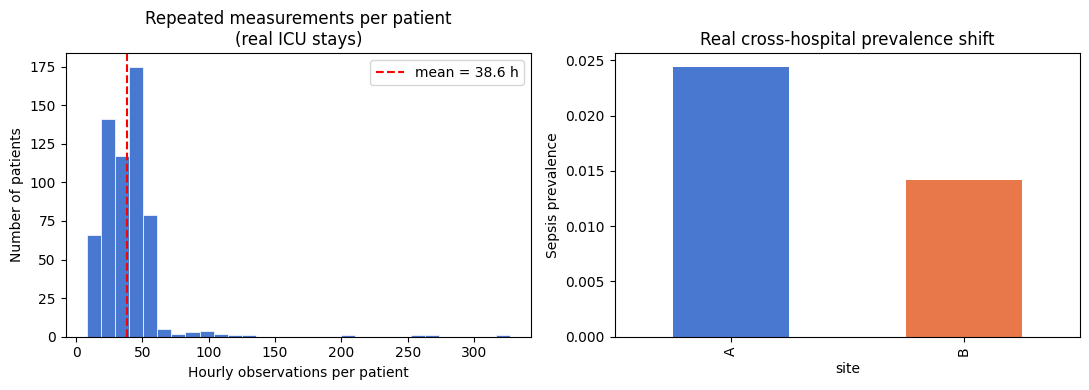

In [7]:
summary = pd.DataFrame({
    "quantity": [
        "hourly rows",
        "features",
        "patients",
        "hospital sites",
        "sepsis prevalence (row-level)",
        "sepsis prevalence (patient-level, ever positive)",
    ],
    "value": [
        X.shape[0],
        X.shape[1],
        np.unique(groups).size,
        np.unique(site).size,
        float(np.mean(y)),
        float(sepsis_df.groupby("patient_id")["SepsisLabel"].max().mean()),
    ],
})
display(summary)

site_table = sepsis_df.groupby("site").agg(
    patients=("patient_id", "nunique"),
    rows=("SepsisLabel", "size"),
    sepsis_prevalence=("SepsisLabel", "mean"),
).reset_index()
display(site_table)

obs_per_patient = sepsis_df.groupby("patient_id").size()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(obs_per_patient, bins=30, color="#4878CF", edgecolor="white", linewidth=0.5)
axes[0].axvline(obs_per_patient.mean(), color="red", ls="--", label=f"mean = {obs_per_patient.mean():.1f} h")
axes[0].set_xlabel("Hourly observations per patient")
axes[0].set_ylabel("Number of patients")
axes[0].set_title("Repeated measurements per patient\n(real ICU stays)")
axes[0].legend()

site_table.set_index("site")["sepsis_prevalence"].plot(kind="bar", ax=axes[1], color=["#4878CF", "#E87849"])
axes[1].set_ylabel("Sepsis prevalence")
axes[1].set_title("Real cross-hospital prevalence shift")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "physionet_sepsis_dataset_diagnostics.png", dpi=300)
plt.show()

## Cell 8 — Define TrustCV splitters and model factory

This notebook now compares three families of validation design:

1. **Leakage-blind row split:** `KFold`, included as the intentionally unsafe comparator.
2. **Patient-safe grouped splits:** `GroupKFold` and `StratifiedGroupKFold`, which prevent the same ICU patient from appearing in both training and validation.
3. **Temporal splitters:** `TimeSeriesSplit`, `BlockedTimeSeries`, `PurgedKFoldCV`, `RollingWindowCV`, and `ExpandingWindowCV` are temporal-only comparators. They respect row/time order to different degrees, but they do **not** automatically protect patient identity unless the method is also group-aware. `PurgedGroupTimeSeriesSplit` combines patient grouping, temporal ordering, and a purge gap, so it is the strictest method for repeated patient-hour data.

The extra temporal splitters are useful for readers because they show a subtle point: **time-aware alone is not enough for repeated-patient clinical data.** A method can be temporal and still leak patient information if the same patient appears in both sides of the split.

In [8]:
def make_model():
    # The imputer is inside the estimator pipeline, so it is fitted only on
    # each training fold. TrustCV still controls the validation split; sklearn
    # is used only as the model backend.
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("rf", RandomForestClassifier(
            n_estimators=N_ESTIMATORS,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced",
            max_depth=12,
        )),
    ])


class PrecomputedSplitter:
    """Wrap an already-computed list of (train_idx, test_idx) folds.

    Some TrustCV temporal splitters need `timestamps=`. UniversalCVRunner sends
    extra keyword arguments both to the splitter and to model fitting, so the
    safest pattern is to precompute temporal folds once, then replay those folds
    through this small splitter wrapper. The validation logic still comes from
    TrustCV; this wrapper only solves an interface mismatch for notebooks.
    """

    def __init__(self, splits, n_splits=None, name="precomputed"):
        self._splits = list(splits)
        self._n_splits = len(self._splits) if n_splits is None else n_splits
        self.name = name

    def split(self, X=None, y=None, groups=None, **kwargs):
        return iter(self._splits)

    def get_n_splits(self, X=None, y=None, groups=None):
        return self._n_splits


def _binary_ok(train_idx, test_idx):
    """Avoid folds where train or validation contains only one label."""
    if len(train_idx) == 0 or len(test_idx) == 0:
        return False
    return len(np.unique(y[train_idx])) == 2 and len(np.unique(y[test_idx])) == 2


def _safe_cache_name(text):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text)).strip("_")


def precompute_temporal_splits(name, splitter, uses_timestamps=True, max_splits=None):
    """Precompute TrustCV temporal folds and keep only usable binary folds.

    The fold indices are cached because some temporal splitters are repeatedly
    reused by plotting, auditing, and runner calls.
    """
    payload = {
        "cache_version": CACHE_VERSION,
        "table_cache_key": TABLE_CACHE_KEY,
        "splitter_name": name,
        "splitter_class": splitter.__class__.__name__,
        "uses_timestamps": bool(uses_timestamps),
        "max_splits": max_splits,
        "n_splits": N_SPLITS,
        "purge_gap_hours": PURGE_GAP_HOURS,
        "embargo_size": EMBARGO_SIZE,
        "n_samples": int(len(y)),
        "n_positive": int(np.sum(y)),
    }
    digest = hashlib.sha256(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:16]
    cache_path = Path(CACHE_DIR) / f"splits_{_safe_cache_name(name)}_{digest}.pkl"

    if USE_CACHE and cache_path.exists() and not FORCE_REBUILD_SPLIT_CACHE:
        print(f"{name}: loading precomputed split cache from {cache_path.name}")
        with open(cache_path, "rb") as f:
            kept = pickle.load(f)
        return PrecomputedSplitter(kept, len(kept), name=name)

    raw = splitter.split(X, y, groups=groups, timestamps=timestamps) if uses_timestamps else splitter.split(X, y, groups=groups)
    kept = []
    skipped = 0
    for train_idx, test_idx in raw:
        train_idx = np.asarray(train_idx)
        test_idx = np.asarray(test_idx)
        if _binary_ok(train_idx, test_idx):
            kept.append((train_idx, test_idx))
        else:
            skipped += 1
        if max_splits is not None and len(kept) >= max_splits:
            break
    if skipped:
        print(f"{name}: skipped {skipped} fold(s) with a single class in train or validation.")
    if len(kept) < 2:
        print(f"Warning: {name} produced only {len(kept)} usable fold(s). It will be omitted.")
        return None

    if USE_CACHE:
        print(f"{name}: saving precomputed split cache to {cache_path.name}")
        tmp_path = cache_path.with_suffix(".tmp")
        with open(tmp_path, "wb") as f:
            pickle.dump(kept, f)
        os.replace(tmp_path, cache_path)

    return PrecomputedSplitter(kept, len(kept), name=name)


# --- Core splitters ---------------------------------------------------------
# Intentionally unsafe row-wise comparator.
cv_methods = {
    "KFold row-wise (naive)": KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    "GroupKFold": GroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    "StratifiedGroupKFold": StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE),
}

validation_role = {
    "KFold row-wise (naive)": "Unsafe row-wise comparator; expected to leak patients",
    "GroupKFold": "Patient-safe grouped validation",
    "StratifiedGroupKFold": "Patient-safe grouped validation with class-balance constraint",
}

# --- Extra temporal-only comparators ---------------------------------------
# These are deliberately labeled as temporal-only: they answer a different
# question than GroupKFold. They are useful because they show whether respecting
# time order alone fixes the leakage problem. In repeated-patient data, it often
# does not; patient grouping is still needed.
if RUN_EXTRA_TEMPORAL_SPLITTERS:
    n_samples = len(X)
    temporal_test_size = max(200, n_samples // (N_SPLITS + 1))
    temporal_block_size = max(200, n_samples // ((N_SPLITS + 1) * 2))
    temporal_initial_train_size = max(500, int(0.40 * n_samples))
    temporal_window_size = max(500, int(0.45 * n_samples))
    temporal_step_size = max(200, int(0.10 * n_samples))
    temporal_horizon = max(200, int(0.10 * n_samples))

    temporal_candidates = {
        "TimeSeriesSplit (temporal-only)": (
            TimeSeriesSplit(n_splits=N_SPLITS, gap=PURGE_GAP_HOURS, test_size=temporal_test_size), True,
            "Time-ordered comparator; may still leak patient identity"
        ),
        "BlockedTimeSeries (temporal-only)": (
            BlockedTimeSeries(n_splits=N_SPLITS, block_size=temporal_block_size), True,
            "Time-block comparator; may still leak patient identity"
        ),
        "PurgedKFoldCV (temporal-only)": (
            PurgedKFoldCV(n_splits=N_SPLITS, purge_gap=PURGE_GAP_HOURS, embargo_size=EMBARGO_SIZE), True,
            "Purged temporal comparator without patient grouping"
        ),
    }

    if RUN_ROLLING_EXPANDING_SPLITTERS:
        temporal_candidates.update({
            "RollingWindowCV (temporal-only)": (
                RollingWindowCV(
                    window_size=temporal_window_size,
                    step_size=temporal_step_size,
                    forecast_horizon=temporal_horizon,
                    gap=PURGE_GAP_HOURS,
                ), False,
                "Rolling/walk-forward temporal comparator without patient grouping"
            ),
            "ExpandingWindowCV (temporal-only)": (
                ExpandingWindowCV(
                    initial_train_size=temporal_initial_train_size,
                    step_size=temporal_step_size,
                    forecast_horizon=temporal_horizon,
                    gap=PURGE_GAP_HOURS,
                ), False,
                "Expanding-window temporal comparator without patient grouping"
            ),
        })

    for name, (splitter, uses_timestamps, role) in temporal_candidates.items():
        wrapped = precompute_temporal_splits(
            name,
            splitter,
            uses_timestamps=uses_timestamps,
            max_splits=MAX_TEMPORAL_COMPARATOR_SPLITS,
        )
        if wrapped is not None:
            cv_methods[name] = wrapped
            validation_role[name] = role

# --- Strict patient + time splitter ----------------------------------------
_purged_group_raw = PurgedGroupTimeSeriesSplit(
    n_splits=N_SPLITS,
    purge_gap=PURGE_GAP_HOURS,
    embargo_size=EMBARGO_SIZE,
    group_exclusive=True,
)
_purged_group_splitter = precompute_temporal_splits(
    "PurgedGroupTimeSeriesSplit",
    _purged_group_raw,
    uses_timestamps=True,
    max_splits=MAX_TEMPORAL_COMPARATOR_SPLITS,
)
if _purged_group_splitter is not None:
    cv_methods["PurgedGroupTimeSeriesSplit"] = _purged_group_splitter
    validation_role["PurgedGroupTimeSeriesSplit"] = "Strict patient-safe + time-aware split with purge gap"

if RUN_PATIENT_LOGO:
    cv_methods["LeaveOneGroupOut (patient)"] = LeaveOneGroupOut()
    validation_role["LeaveOneGroupOut (patient)"] = "Strict patient holdout; one fold per patient"

print("Configured TrustCV validation methods:")
for name, cv in cv_methods.items():
    try:
        n = cv.get_n_splits(X, y, groups)
    except Exception:
        n = cv.get_n_splits()
    print(f"- {name}: {n} folds | {validation_role.get(name, '')}")


TimeSeriesSplit (temporal-only): saving precomputed split cache to splits_TimeSeriesSplit_temporal-only_f9e22f092a116e5b.pkl
BlockedTimeSeries (temporal-only): saving precomputed split cache to splits_BlockedTimeSeries_temporal-only_6d93a48c1f119911.pkl
PurgedKFoldCV (temporal-only): saving precomputed split cache to splits_PurgedKFoldCV_temporal-only_276fe0fa76b2804c.pkl
RollingWindowCV (temporal-only): saving precomputed split cache to splits_RollingWindowCV_temporal-only_964828c7eaf5c57d.pkl
ExpandingWindowCV (temporal-only): saving precomputed split cache to splits_ExpandingWindowCV_temporal-only_8c4bba48037becf4.pkl
PurgedGroupTimeSeriesSplit: saving precomputed split cache to splits_PurgedGroupTimeSeriesSplit_9591c6504a4a4379.pkl
Configured TrustCV validation methods:
- KFold row-wise (naive): 5 folds | Unsafe row-wise comparator; expected to leak patients
- GroupKFold: 5 folds | Patient-safe grouped validation
- StratifiedGroupKFold: 5 folds | Patient-safe grouped validation wit

## Cell 9 — Visualize TrustCV split behavior on real clinical rows

`plot_grouped_cv` comes from TrustCV. For row-wise K-Fold, a patient's hourly rows are scattered across folds. For `GroupKFold` and `PurgedGroupTimeSeriesSplit`, each patient's rows stay together, and `PurgedGroupTimeSeriesSplit` additionally respects the global time ordering.

In [9]:
# Note: plot_grouped_cv visualizes split membership. For precomputed temporal
# splitters, this is the real set of train/test indices used by the notebook.
plot_names = [
    "KFold row-wise (naive)",
    "GroupKFold",
    "TimeSeriesSplit (temporal-only)",
    "PurgedKFoldCV (temporal-only)",
    "PurgedGroupTimeSeriesSplit",
]
plot_names = [p for p in plot_names if p in cv_methods]

for plot_name in plot_names:
    try:
        ax = plot_grouped_cv(
            cv_methods[plot_name],
            groups=groups,
            n_splits=cv_methods[plot_name].get_n_splits(X, y, groups),
            figsize=(10, 4),
            title=f"TrustCV split visualization: {plot_name}",
        )
        plt.tight_layout()
        safe_name = plot_name.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
        plt.savefig(Path(OUTPUT_DIR) / f"{safe_name}_trustcv_split.png", dpi=300)
        plt.show()
    except Exception as exc:
        print(f"Could not plot {plot_name}: {exc}")


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7eca89e3a160> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7eca89e1fa60> (for post_execute):


KeyboardInterrupt: 

## Cell 10 — Helper functions for pooled and patient-macro clinical metrics

Reused pattern from the UCI HAR notebook: `oob_clinical_metrics` gives pooled observation-level metrics from TrustCV's `CVResults`; `patient_macro_clinical_metrics` applies TrustCV's `ClinicalMetrics` within each patient and averages the patient-level values.

In [10]:
def extract_oob_arrays(cv_result, y):
    y = np.asarray(y)
    y_true_all, y_pred_all, y_proba_all, test_index_all = [], [], [], []

    for (train_idx, test_idx), fold_scores in zip(cv_result.indices, cv_result.scores):
        y_true_all.append(y[test_idx])
        test_index_all.append(np.asarray(test_idx))

        pred = fold_scores.get("predictions")
        if pred is None:
            pred = fold_scores.get("y_pred")
        y_pred_all.append(np.asarray(pred).ravel())

        prob = fold_scores.get("probabilities")
        if prob is None:
            prob = fold_scores.get("y_proba")
        prob = np.asarray(prob)
        if prob.ndim == 2 and prob.shape[1] > 1:
            prob = prob[:, 1]
        y_proba_all.append(prob.ravel())

    test_indices = np.concatenate(test_index_all)
    return {
        "test_indices": test_indices,
        "y_true": np.concatenate(y_true_all),
        "y_pred": np.concatenate(y_pred_all),
        "y_proba": np.concatenate(y_proba_all),
    }


def patient_macro_clinical_metrics(cv_result, y, groups):
    oob = extract_oob_arrays(cv_result, y)
    patient_ids = np.asarray(groups)[oob["test_indices"]]
    clinical = ClinicalMetrics(confidence_level=0.95, prevalence=float(np.mean(y)))

    rows = []
    for pid in np.unique(patient_ids):
        m = patient_ids == pid
        if len(np.unique(oob["y_true"][m])) < 2:
            continue
        metrics = clinical.calculate_all(
            y_true=oob["y_true"][m],
            y_pred=oob["y_pred"][m],
            y_proba=oob["y_proba"][m],
        )
        rows.append({
            "patient_id": int(pid),
            "auc_roc": float(metrics.get("auc_roc", np.nan)),
            "sensitivity": float(metrics.get("sensitivity", np.nan)),
            "specificity": float(metrics.get("specificity", np.nan)),
            "youdens_index": float(metrics.get("youdens_index", np.nan)),
            "accuracy": float(metrics.get("accuracy", np.nan)),
        })

    patient_df = pd.DataFrame(rows)
    macro = patient_df.drop(columns=["patient_id"]).mean(numeric_only=True).to_dict()
    macro_sd = patient_df.drop(columns=["patient_id"]).std(numeric_only=True).add_suffix("_sd").to_dict()
    return {**macro, **macro_sd, "n_patients": int(patient_df.shape[0])}, patient_df


def run_trustcv_method(method_name, splitter, split_groups=None):
    """Run one TrustCV CV method end-to-end.

    `split_groups` controls what the splitter itself groups by (defaults to
    real patient IDs; pass `site` for the cross-hospital experiment). Patient
    IDs are always used for the patient-macro clinical metrics, regardless of
    what the splitter grouped on, since "patient" is the natural unit for
    that aggregation either way.
    """
    print("=" * 80)
    print(method_name)
    print("=" * 80)

    active_groups = groups if split_groups is None else split_groups
    runner = UniversalCVRunner(cv_splitter=splitter, framework="sklearn", verbose=2)

    callbacks = [
        LeakageDetectionCallback(data=(X_AUDIT, y), groups=active_groups, timestamps=timestamps, verbose=2),
        ClassDistributionLogger(labels=y, label_names={0: "no sepsis", 1: "sepsis"}, verbose=2),
    ]

    cv_result = runner.run(
        model=make_model,
        data=(X, y, active_groups),
        groups=active_groups,
        metrics=["accuracy", "balanced_accuracy", "f1", "precision", "recall", "roc_auc"],
        callbacks=callbacks,
    )

    clinical = ClinicalMetrics(confidence_level=0.95, prevalence=float(np.mean(y)))
    pooled = oob_clinical_metrics(cv_result, y, clinical=clinical)
    macro, patient_df = patient_macro_clinical_metrics(cv_result, y, groups)

    print(cv_result.summary())
    print("Pooled OOB clinical metrics (trustcv.metrics.oob_clinical_metrics):")
    for key in ["auc_roc", "sensitivity", "specificity", "youdens_index", "accuracy"]:
        print(f"  {key}: {pooled.get(key, np.nan):.4f}")
    print("Patient-macro clinical metrics (trustcv.ClinicalMetrics per patient):")
    for key in ["auc_roc", "sensitivity", "specificity", "youdens_index", "accuracy"]:
        print(f"  {key}: {macro.get(key, np.nan):.4f}")

    return {
        "method": method_name,
        "splitter": splitter,
        "cv_result": cv_result,
        "pooled": pooled,
        "patient_macro": macro,
        "patient_df": patient_df,
    }

## Cell 11 — Run TrustCV validation methods on real PhysioNet sepsis data

This is the main experiment. Watch the TrustCV leakage messages: row-wise K-Fold should be flagged for patient overlap (and, being unordered, will also violate temporal order), while `GroupKFold`/`StratifiedGroupKFold` should pass the patient check, and `PurgedGroupTimeSeriesSplit` should pass both the patient and temporal checks.

In [11]:
def cv_results_cache_path(label, extra_payload=None):
    payload = {
        "cache_version": CACHE_VERSION,
        "label": label,
        "table_cache_key": TABLE_CACHE_KEY,
        "cv_methods": list(cv_methods.keys()),
        "n_splits": N_SPLITS,
        "n_estimators": N_ESTIMATORS,
        "nested_inner_splits": NESTED_INNER_SPLITS,
        "run_extra_temporal_splitters": RUN_EXTRA_TEMPORAL_SPLITTERS,
        "run_rolling_expanding_splitters": RUN_ROLLING_EXPANDING_SPLITTERS,
        "purge_gap_hours": PURGE_GAP_HOURS,
        "embargo_size": EMBARGO_SIZE,
        "random_state": RANDOM_STATE,
    }
    if extra_payload:
        payload.update(extra_payload)
    digest = hashlib.sha256(json.dumps(payload, sort_keys=True).encode("utf-8")).hexdigest()[:16]
    return Path(CACHE_DIR) / f"{label}_{digest}.pkl"


def atomic_pickle_dump(obj, path):
    """Write pickle safely: write temp file first, then atomically replace."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    pd.to_pickle(obj, tmp_path)
    os.replace(tmp_path, path)


main_cv_cache = cv_results_cache_path("trustcv_results_main")
main_cv_checkpoint = main_cv_cache.with_name(main_cv_cache.stem + "_checkpoint.pkl")

if USE_CACHE and CACHE_CV_RESULTS and main_cv_cache.exists() and not FORCE_RERUN_CV:
    print("Loading complete TrustCV results from cache:", main_cv_cache)
    trustcv_results = pd.read_pickle(main_cv_cache)
else:
    trustcv_results = {}

    if (
        USE_CACHE and CACHE_CV_RESULTS and CHECKPOINT_EACH_CV_METHOD
        and main_cv_checkpoint.exists() and not FORCE_RERUN_CV
    ):
        print("Loading partial TrustCV checkpoint:", main_cv_checkpoint)
        trustcv_results = pd.read_pickle(main_cv_checkpoint)
        print("Already completed methods:", list(trustcv_results.keys()))

    for method_name, splitter in cv_methods.items():
        if method_name in trustcv_results and not FORCE_RERUN_CV:
            print(f"Skipping {method_name}: found in checkpoint.")
            continue

        trustcv_results[method_name] = run_trustcv_method(method_name, splitter)

        # Save immediately after each completed method. This allows resume after
        # a Colab crash/runtime reset without rerunning earlier methods.
        if USE_CACHE and CACHE_CV_RESULTS and CHECKPOINT_EACH_CV_METHOD:
            print("Saving partial TrustCV checkpoint:", main_cv_checkpoint)
            try:
                atomic_pickle_dump(trustcv_results, main_cv_checkpoint)
            except Exception as exc:
                print("Warning: could not save partial TrustCV checkpoint:", exc)

    if USE_CACHE and CACHE_CV_RESULTS:
        print("Saving complete TrustCV results cache:", main_cv_cache)
        try:
            atomic_pickle_dump(trustcv_results, main_cv_cache)
            # Keep the checkpoint too; it is useful provenance and allows easy inspection.
        except Exception as exc:
            print("Warning: could not cache complete TrustCV result objects:", exc)

Streaming output truncated to the last 5000 lines.
Fold 309:
  Training samples: 23132
  Validation samples: 30
  Training groups: 599
  Validation groups: 1
  [LeakageDetection] Fold 308: leakage detected — severity=high, types=['temporal', 'near_duplicate']
  Train class distribution: no sepsis: 22687 (98.1%), sepsis: 445 (1.9%)
  Val class distribution:   no sepsis: 30 (100.0%)
Fold 309 completed
  score: 1.0000
  accuracy: 1.0000
  f1: 0.0000
  precision: 0.0000
  recall: 0.0000
  balanced_accuracy: 1.0000
  roc_auc: nan

Fold 310:
  Training samples: 23146
  Validation samples: 16
  Training groups: 599
  Validation groups: 1
  [LeakageDetection] Fold 309: leakage detected — severity=high, types=['temporal', 'near_duplicate']
  Train class distribution: no sepsis: 22701 (98.1%), sepsis: 445 (1.9%)
  Val class distribution:   no sepsis: 16 (100.0%)
Fold 310 completed
  score: 1.0000
  accuracy: 1.0000
  f1: 0.0000
  precision: 0.0000
  recall: 0.0000
  balanced_accuracy: 1.0000
  r

## Cell 12 — Explicit leakage and temporal audit with `DataLeakageChecker`

This checks patient overlap **and** temporal ordering using TrustCV `DataLeakageChecker.check_cv_splits` on the first fold of each method — the same explicit-audit pattern used in the UCI HAR notebook, extended here with the `timestamps_train`/`timestamps_test` arguments to also catch temporal violations, which is only meaningful because this is real time-ordered clinical data.

In [12]:
def explicit_leakage_audit(method_name, splitter):
    """Audit one fold and separate patient leakage from temporal/near-duplicate warnings.

    This distinction is the main correction in this notebook:
      - KFold row-wise should FLAG patient-overlap leakage.
      - GroupKFold and StratifiedGroupKFold should PASS patient-overlap leakage.
      - Grouped methods may still have temporal/near-duplicate warnings because
        they are patient-safe but not necessarily deployment-time-safe.
      - PurgedGroupTimeSeriesSplit should PASS patient overlap and temporal ordering.
    """
    checker = DataLeakageChecker(verbose=False)
    train_idx, test_idx = next(iter(splitter.split(X, y, groups=groups)))

    report = checker.check_cv_splits(
        X_AUDIT[train_idx], X_AUDIT[test_idx],
        y_train=y[train_idx], y_test=y[test_idx],
        patient_ids_train=groups[train_idx], patient_ids_test=groups[test_idx],
        timestamps_train=timestamps[train_idx], timestamps_test=timestamps[test_idx],
    )
    leakage_types = list(report.leakage_types) if report.leakage_types else []
    shared_patients = sorted(set(groups[train_idx]) & set(groups[test_idx]))
    temporal_violation = (
        len(train_idx) > 0 and len(test_idx) > 0
        and timestamps[train_idx].max() > timestamps[test_idx].min()
    )
    has_patient_leakage = (len(shared_patients) > 0) or ("patient" in leakage_types)
    has_temporal_warning = temporal_violation or ("temporal" in leakage_types)
    has_near_duplicate_warning = "near_duplicate" in leakage_types

    return {
        "CV method": method_name,
        "train_patients": len(set(groups[train_idx])),
        "test_patients": len(set(groups[test_idx])),
        "shared_patients": len(shared_patients),
        "trustcv_leakage_types": ", ".join(leakage_types) if leakage_types else "none",
        "trustcv_severity": report.severity,
        "patient_overlap_verdict": "FLAG" if has_patient_leakage else "PASS",
        "temporal_ordering_verdict": "FLAG" if has_temporal_warning else "PASS",
        "near_duplicate_warning": "WARN" if has_near_duplicate_warning else "PASS",
        "method_interpretation": (
            "Invalid for repeated-patient data: same patient appears in train and validation"
            if has_patient_leakage else
            "Patient-safe but not fully time-aware" if has_temporal_warning else
            "Patient-safe and time-order-safe in the audited fold"
        ),
    }

leakage_table = pd.DataFrame([
    explicit_leakage_audit(name, splitter)
    for name, splitter in cv_methods.items()
])

display(leakage_table)
leakage_table.to_csv(Path(OUTPUT_DIR) / "physionet_sepsis_leakage_audit.csv", index=False)

,CV method,train_patients,test_patients,shared_patients,trustcv_leakage_types,trustcv_severity,patient_overlap_verdict,temporal_ordering_verdict,near_duplicate_warning,method_interpretation
0,KFold row-wise (naive),600,594,594,"patient, temporal, near_duplicate",critical,FLAG,FLAG,WARN,Invalid for repeated-patient data: same patien...
1,GroupKFold,480,120,0,"temporal, near_duplicate",high,PASS,FLAG,WARN,Patient-safe but not fully time-aware
2,StratifiedGroupKFold,480,120,0,"temporal, near_duplicate",high,PASS,FLAG,WARN,Patient-safe but not fully time-aware
3,TimeSeriesSplit (temporal-only),105,99,1,"patient, near_duplicate",critical,FLAG,PASS,WARN,Invalid for repeated-patient data: same patien...
4,BlockedTimeSeries (temporal-only),105,99,1,"patient, near_duplicate",critical,FLAG,PASS,WARN,Invalid for repeated-patient data: same patien...
5,PurgedKFoldCV (temporal-only),469,125,0,"temporal, near_duplicate",high,PASS,FLAG,WARN,Patient-safe but not fully time-aware
6,RollingWindowCV (temporal-only),273,56,0,near_duplicate,high,PASS,PASS,WARN,Patient-safe and time-order-safe in the audite...
7,ExpandingWindowCV (temporal-only),247,59,1,"patient, near_duplicate",critical,FLAG,PASS,WARN,Invalid for repeated-patient data: same patien...
8,PurgedGroupTimeSeriesSplit,104,99,0,near_duplicate,high,PASS,PASS,WARN,Patient-safe and time-order-safe in the audite...
9,LeaveOneGroupOut (patient),599,1,0,"temporal, near_duplicate",high,PASS,FLAG,WARN,Patient-safe but not fully time-aware


## Cell 13 — Cross-hospital external validation with `LeaveOneGroupOut`

This is the piece that is only possible because the public Challenge data genuinely spans **two separate hospital systems**. Using `LeaveOneGroupOut` with `groups=site` gives exactly two folds — train on hospital A / test on hospital B, and vice versa — which is the real-world "does this generalize to a new hospital" question reviewers ask about clinical ML, demonstrated on real institutional data rather than a synthetic site label.

In [13]:
site_logo = LeaveOneGroupOut()
print("Cross-hospital LeaveOneGroupOut folds:", site_logo.get_n_splits(X, y, site))

cross_site_cache = cv_results_cache_path(
    "trustcv_results_cross_site",
    extra_payload={"split_groups": "site"},
)

if USE_CACHE and CACHE_CV_RESULTS and cross_site_cache.exists() and not FORCE_RERUN_CV:
    print("Loading cross-site TrustCV results from cache:", cross_site_cache)
    cross_site_bundle = pd.read_pickle(cross_site_cache)
    cross_site_result = cross_site_bundle["cross_site_result"]
    cross_site_leakage_table = cross_site_bundle["cross_site_leakage_table"]
else:
    cross_site_result = run_trustcv_method(
        "LeaveOneGroupOut (hospital site)",
        site_logo,
        split_groups=site,
    )
    # Re-run the callback-based leakage/fold accounting using `site` as the group,
    # since the main loop above always audits patient-level grouping.
    cross_site_leakage_rows = []
    for fold_i, (train_idx, test_idx) in enumerate(site_logo.split(X, y, groups=site), start=1):
        checker = DataLeakageChecker(verbose=False)
        report = checker.check_cv_splits(
            X_AUDIT[train_idx], X_AUDIT[test_idx],
            y_train=y[train_idx], y_test=y[test_idx],
            patient_ids_train=groups[train_idx], patient_ids_test=groups[test_idx],
        )
        train_sites = sorted(set(site[train_idx]))
        test_sites = sorted(set(site[test_idx]))
        cross_site_leakage_rows.append({
            "fold": fold_i,
            "train_site(s)": train_sites,
            "test_site(s)": test_sites,
            "train_patients": len(set(groups[train_idx])),
            "test_patients": len(set(groups[test_idx])),
            "shared_patients_train_test": len(set(groups[train_idx]) & set(groups[test_idx])),
            "leakage_types": ", ".join(report.leakage_types) if report.leakage_types else "none",
            "patient_overlap_verdict": "FLAG" if (len(set(groups[train_idx]) & set(groups[test_idx])) > 0 or "patient" in report.leakage_types) else "PASS",
        })

    cross_site_leakage_table = pd.DataFrame(cross_site_leakage_rows)

    if USE_CACHE and CACHE_CV_RESULTS:
        print("Saving cross-site TrustCV results cache:", cross_site_cache)
        try:
            atomic_pickle_dump(
                {
                    "cross_site_result": cross_site_result,
                    "cross_site_leakage_table": cross_site_leakage_table,
                },
                cross_site_cache,
            )
        except Exception as exc:
            print("Warning: could not cache cross-site TrustCV result objects:", exc)

display(cross_site_leakage_table)
cross_site_leakage_table.to_csv(Path(OUTPUT_DIR) / "physionet_sepsis_cross_site_leakage_audit.csv", index=False)

Cross-hospital LeaveOneGroupOut folds: 2
LeaveOneGroupOut (hospital site)
Using sklearn adapter for cross-validation
Starting None-fold cross-validation

Fold 1:
  Training samples: 11737
  Validation samples: 11425
  Training groups: 1
  Validation groups: 1
  [LeakageDetection] Fold 0: leakage detected — severity=high, types=['temporal', 'near_duplicate']
  Train class distribution: no sepsis: 11571 (98.6%), sepsis: 166 (1.4%)
  Val class distribution:   no sepsis: 11146 (97.6%), sepsis: 279 (2.4%)
Fold 1 completed
  score: 0.9753
  accuracy: 0.9753
  f1: 0.0000
  precision: 0.0000
  recall: 0.0000
  balanced_accuracy: 0.4999
  roc_auc: 0.6460

Fold 2:
  Training samples: 11425
  Validation samples: 11737
  Training groups: 1
  Validation groups: 1
  [LeakageDetection] Fold 1: leakage detected — severity=high, types=['near_duplicate']
  Train class distribution: no sepsis: 11146 (97.6%), sepsis: 279 (2.4%)
  Val class distribution:   no sepsis: 11571 (98.6%), sepsis: 166 (1.4%)
Fold 

,fold,train_site(s),test_site(s),train_patients,test_patients,shared_patients_train_test,leakage_types,patient_overlap_verdict
0,1,[B],[A],300,300,0,near_duplicate,PASS
1,2,[A],[B],300,300,0,near_duplicate,PASS


## Cell 14 — Build the manuscript-style comparison table

Pooled observation-level and patient-macro metrics, with the leakage verdict from TrustCV's explicit checker, for every within-hospital validation method plus the cross-hospital external-validation row.

In [14]:
def fmt_metric(value, digits=3):
    if value is None or pd.isna(value):
        return "NA"
    return f"{float(value):.{digits}f}"


def fmt_ci(value, ci, digits=3):
    if value is None or pd.isna(value):
        return "NA"
    if ci is None or len(ci) != 2:
        return fmt_metric(value, digits)
    return f"{float(value):.{digits}f} ({float(ci[0]):.{digits}f}, {float(ci[1]):.{digits}f})"


reference_method = "GroupKFold"
reference_obs_auc = trustcv_results[reference_method]["pooled"].get("auc_roc")
reference_patient_auc = trustcv_results[reference_method]["patient_macro"].get("auc_roc")

rows = []
for method_name, result in trustcv_results.items():
    pooled = result["pooled"]
    macro = result["patient_macro"]
    leak_row = leakage_table.loc[leakage_table["CV method"] == method_name]
    leak = leak_row.iloc[0] if len(leak_row) else None
    rows.append({
        "CV method": method_name,
        "Validation role": validation_role.get(method_name, ""),
        "Obs. AUC (95% CI)": fmt_ci(pooled.get("auc_roc"), pooled.get("auc_roc_ci")),
        "Obs. Sens. @0.5": fmt_metric(pooled.get("sensitivity")),
        "Obs. Spec. @0.5": fmt_metric(pooled.get("specificity")),
        "Obs. Youden J @0.5": fmt_metric(pooled.get("youdens_index")),
        "Patient-macro AUC": fmt_metric(macro.get("auc_roc")),
        "Delta Obs. AUC vs GroupKFold": "Ref" if method_name == reference_method else fmt_metric(pooled.get("auc_roc") - reference_obs_auc),
        "Delta Patient AUC vs GroupKFold": "Ref" if method_name == reference_method else fmt_metric(macro.get("auc_roc") - reference_patient_auc),
        "Patient-overlap leakage": leak["patient_overlap_verdict"] if leak is not None else "NA",
        "Temporal-order warning": leak["temporal_ordering_verdict"] if leak is not None else "NA",
        "Near-duplicate warning": leak["near_duplicate_warning"] if leak is not None else "NA",
        "TrustCV leakage types": leak["trustcv_leakage_types"] if leak is not None else "NA",
        "Shared patients (first fold)": int(leak["shared_patients"]) if leak is not None else np.nan,
    })

# Cross-hospital external validation row (separate reference frame: honest
# external-generalization AUC, not compared against the within-hospital
# GroupKFold reference).
cross_pooled = cross_site_result["pooled"]
cross_macro = cross_site_result["patient_macro"]
rows.append({
    "CV method": "LeaveOneGroupOut (hospital site, external)",
    "Validation role": "Cross-site external validation",
    "Obs. AUC (95% CI)": fmt_ci(cross_pooled.get("auc_roc"), cross_pooled.get("auc_roc_ci")),
    "Obs. Sens. @0.5": fmt_metric(cross_pooled.get("sensitivity")),
    "Obs. Spec. @0.5": fmt_metric(cross_pooled.get("specificity")),
    "Obs. Youden J @0.5": fmt_metric(cross_pooled.get("youdens_index")),
    "Patient-macro AUC": fmt_metric(cross_macro.get("auc_roc")),
    "Delta Obs. AUC vs GroupKFold": "External (not comparable)",
    "Delta Patient AUC vs GroupKFold": "External (not comparable)",
    "Patient-overlap leakage": "PASS",
    "Temporal-order warning": "External split",
    "Near-duplicate warning": "See cross-site audit",
    "TrustCV leakage types": ", ".join(cross_site_leakage_table["leakage_types"].unique()),
    "Shared patients (first fold)": 0,
})

manuscript_table = pd.DataFrame(rows)
display(manuscript_table)

manuscript_table.to_csv(Path(OUTPUT_DIR) / "physionet_sepsis_manuscript_table.csv", index=False)
with open(Path(OUTPUT_DIR) / "physionet_sepsis_manuscript_table.md", "w", encoding="utf-8") as f:
    f.write(manuscript_table.to_markdown(index=False))

,CV method,Validation role,Obs. AUC (95% CI),Obs. Sens. @0.5,Obs. Spec. @0.5,Obs. Youden J @0.5,Patient-macro AUC,Delta Obs. AUC vs GroupKFold,Delta Patient AUC vs GroupKFold,Patient-overlap leakage,Temporal-order warning,Near-duplicate warning,TrustCV leakage types,Shared patients (first fold)
0,KFold row-wise (naive),Unsafe row-wise comparator; expected to leak p...,"0.995 (0.993, 0.997)",0.881,0.994,0.875,0.964,0.262,0.295,FLAG,FLAG,WARN,"patient, temporal, near_duplicate",594
1,GroupKFold,Patient-safe grouped validation,"0.733 (0.710, 0.758)",0.009,0.995,0.004,0.669,Ref,Ref,PASS,FLAG,WARN,"temporal, near_duplicate",0
2,StratifiedGroupKFold,Patient-safe grouped validation with class-bal...,"0.743 (0.719, 0.766)",0.011,0.996,0.008,0.676,0.011,0.007,PASS,FLAG,WARN,"temporal, near_duplicate",0
3,TimeSeriesSplit (temporal-only),Time-ordered comparator; may still leak patien...,"0.714 (0.683, 0.743)",0.000,1.000,-0.000,0.750,-0.019,0.081,FLAG,PASS,WARN,"patient, near_duplicate",1
4,BlockedTimeSeries (temporal-only),Time-block comparator; may still leak patient ...,"0.720 (0.687, 0.750)",0.000,1.000,-0.000,0.759,-0.013,0.091,FLAG,PASS,WARN,"patient, near_duplicate",1
5,PurgedKFoldCV (temporal-only),Purged temporal comparator without patient gro...,"0.723 (0.698, 0.747)",0.011,0.998,0.009,0.651,-0.010,-0.018,PASS,FLAG,WARN,"temporal, near_duplicate",0
6,RollingWindowCV (temporal-only),Rolling/walk-forward temporal comparator witho...,"0.688 (0.645, 0.734)",0.000,1.000,-0.000,0.753,-0.044,0.085,PASS,PASS,WARN,near_duplicate,0
7,ExpandingWindowCV (temporal-only),Expanding-window temporal comparator without p...,"0.689 (0.646, 0.730)",0.000,1.000,-0.000,0.677,-0.044,0.008,FLAG,PASS,WARN,"patient, near_duplicate",1
8,PurgedGroupTimeSeriesSplit,Strict patient-safe + time-aware split with pu...,"0.731 (0.701, 0.758)",0.000,1.000,-0.000,0.744,-0.002,0.075,PASS,PASS,WARN,near_duplicate,0
9,LeaveOneGroupOut (patient),Strict patient holdout; one fold per patient,"0.742 (0.717, 0.766)",0.013,0.994,0.008,0.697,0.009,0.028,PASS,FLAG,WARN,"temporal, near_duplicate",0


## Cell 15 — Performance and leakage plots

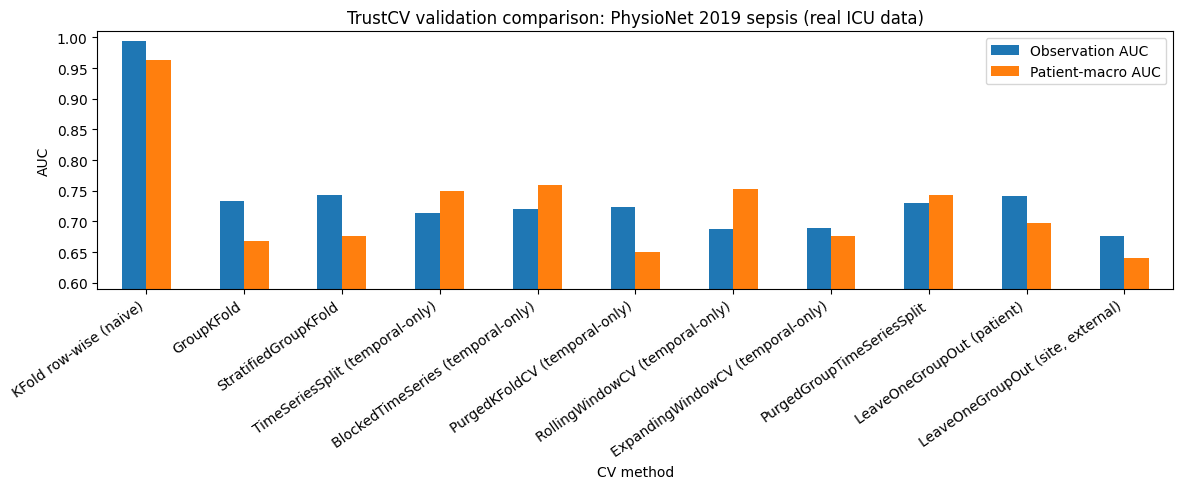

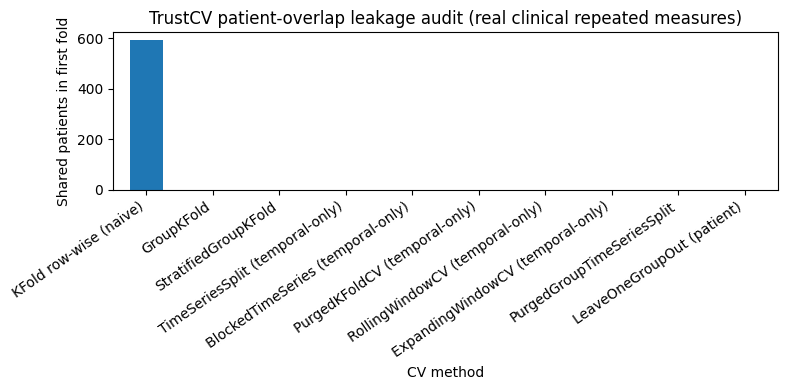

In [15]:
plot_df = []
for method_name, result in trustcv_results.items():
    plot_df.append({
        "CV method": method_name,
        "Observation AUC": result["pooled"].get("auc_roc"),
        "Patient-macro AUC": result["patient_macro"].get("auc_roc"),
    })
plot_df.append({
    "CV method": "LeaveOneGroupOut (site, external)",
    "Observation AUC": cross_site_result["pooled"].get("auc_roc"),
    "Patient-macro AUC": cross_site_result["patient_macro"].get("auc_roc"),
})
plot_df = pd.DataFrame(plot_df).set_index("CV method")

fig, ax = plt.subplots(figsize=(12, 5))
plot_df.plot(kind="bar", ax=ax)
ax.set_ylim(max(0.4, float(plot_df.min().min()) - 0.05), 1.01)
ax.set_ylabel("AUC")
ax.set_title("TrustCV validation comparison: PhysioNet 2019 sepsis (real ICU data)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "physionet_sepsis_auc_comparison.png", dpi=300)
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
leakage_table.set_index("CV method")["shared_patients"].plot(kind="bar", ax=ax)
ax.set_ylabel("Shared patients in first fold")
ax.set_title("TrustCV patient-overlap leakage audit (real clinical repeated measures)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "physionet_sepsis_patient_overlap.png", dpi=300)
plt.show()

## Cell 16 — `NestedGroupedCV` with inner grouped tuning

Adds nested cross-validation with an outer patient-group-disjoint evaluation loop and an inner patient-group-disjoint tuning loop, using TrustCV's validator-level `NestedGroupedCV` (as in the UCI HAR notebook). The native object returns fold-level ROC AUC, balanced accuracy, AUPRC, F1, and the tuned hyperparameters; it does not expose full out-of-fold predictions, so sensitivity/specificity are not computed for this row.

In [16]:
if RUN_NESTED:
    nested_cache = cv_results_cache_path(
        "trustcv_results_nested",
        extra_payload={"nested": True, "inner_splits": NESTED_INNER_SPLITS},
    )

    if USE_CACHE and CACHE_CV_RESULTS and nested_cache.exists() and not FORCE_RERUN_CV:
        print("Loading NestedGroupedCV results from cache:", nested_cache)
        nested_bundle = pd.read_pickle(nested_cache)
        nested_per_fold = nested_bundle["nested_per_fold"]
        nested_summary = nested_bundle["nested_summary"]
        nested_summary_table = nested_bundle["nested_summary_table"]
    else:
        print("Running TrustCV NestedGroupedCV with inner grouped tuning on real sepsis data...")
        nested_param_grid = {
            "rf__max_depth": [8, 12] if SMOKE_MODE else [8, 12, 16],
            "rf__min_samples_leaf": [1] if SMOKE_MODE else [1, 2],
        }

        trustcv_nested = TrustCVNestedGroupedCV(
            n_splits_outer=N_SPLITS,
            n_splits_inner=NESTED_INNER_SPLITS,
            scoring="roc_auc",
            mode="group",
        )

        nested_per_fold, nested_summary = trustcv_nested.fit_predict(
            estimator=make_model(),
            X=X, y=y, groups=groups,
            param_grid=nested_param_grid,
        )

        nested_leakage = explicit_leakage_audit("NestedGroupedCV (outer folds)", trustcv_nested.outer_cv)

        nested_auc_mean = float(nested_per_fold["roc_auc"].mean())
        nested_auc_sd = float(nested_per_fold["roc_auc"].std())
        nested_bal_acc_mean = float(nested_per_fold["balanced_accuracy"].mean())

        nested_summary_table = pd.DataFrame([{
            "CV method": "NestedGroupedCV",
            "Outer folds": int(nested_per_fold.shape[0]),
            "Inner folds": int(NESTED_INNER_SPLITS),
            "Outer ROC AUC mean": nested_auc_mean,
            "Outer ROC AUC SD": nested_auc_sd,
            "Outer balanced accuracy mean": nested_bal_acc_mean,
            "Tuned parameters": str(nested_param_grid),
            "Patient-overlap leakage": nested_leakage["patient_overlap_verdict"],
            "Temporal-order warning": nested_leakage["temporal_ordering_verdict"],
            "Near-duplicate warning": nested_leakage["near_duplicate_warning"],
            "TrustCV leakage types": nested_leakage["trustcv_leakage_types"],
            "Shared patients in first outer fold": int(nested_leakage["shared_patients"]),
        }])

        if USE_CACHE and CACHE_CV_RESULTS:
            print("Saving NestedGroupedCV results cache:", nested_cache)
            try:
                atomic_pickle_dump(
                    {
                        "nested_per_fold": nested_per_fold,
                        "nested_summary": nested_summary,
                        "nested_summary_table": nested_summary_table,
                    },
                    nested_cache,
                )
            except Exception as exc:
                print("Warning: could not cache NestedGroupedCV result objects:", exc)

    print("Nested grouped per-fold results:")
    display(nested_per_fold)
    print("Nested grouped summary:")
    display(nested_summary)
    print("Nested grouped diagnostic table:")
    display(nested_summary_table)

    nested_per_fold.to_csv(Path(OUTPUT_DIR) / "physionet_sepsis_nested_grouped_per_fold.csv", index=False)
    nested_summary.to_csv(Path(OUTPUT_DIR) / "physionet_sepsis_nested_grouped_summary.csv")
    nested_summary_table.to_csv(Path(OUTPUT_DIR) / "physionet_sepsis_nested_grouped_diagnostic.csv", index=False)
else:
    print("NestedGroupedCV skipped. Set RUN_NESTED=True in Cell 1 to run it.")

Running TrustCV NestedGroupedCV with inner grouped tuning on real sepsis data...
Saving NestedGroupedCV results cache: /content/drive/MyDrive/trustcv_physionet_resume_cache/cache/trustcv_results_nested_29c868b9655fe8fd.pkl
Nested grouped per-fold results:


,fold,balanced_accuracy,roc_auc,auprc,f1,best_params
0,1,0.499890,0.779242,0.043671,0.000000,"{'rf__max_depth': 12, 'rf__min_samples_leaf': 1}"
1,2,0.500000,0.734007,0.062545,0.000000,"{'rf__max_depth': 12, 'rf__min_samples_leaf': 1}"
2,3,0.495149,0.757585,0.073646,0.000000,"{'rf__max_depth': 12, 'rf__min_samples_leaf': 1}"
3,4,0.555821,0.698758,0.131222,0.178571,"{'rf__max_depth': 8, 'rf__min_samples_leaf': 1}"
4,5,0.548927,0.838215,0.086858,0.108108,"{'rf__max_depth': 8, 'rf__min_samples_leaf': 1}"


Nested grouped summary:


,balanced_accuracy,roc_auc,auprc,f1
mean,0.519957,0.761562,0.079588,0.057336
std,0.029757,0.052220,0.032919,0.082368


Nested grouped diagnostic table:


,CV method,Outer folds,Inner folds,Outer ROC AUC mean,Outer ROC AUC SD,Outer balanced accuracy mean,Tuned parameters,Patient-overlap leakage,Temporal-order warning,Near-duplicate warning,TrustCV leakage types,Shared patients in first outer fold
0,NestedGroupedCV,5,3,0.761562,0.05222,0.519957,"{'rf__max_depth': [8, 12], 'rf__min_samples_le...",PASS,FLAG,WARN,"temporal, near_duplicate",0


## Cell 17 — Export all outputs

Creates a zip file containing tables and figures for download from Colab.

In [17]:
import shutil

for method_name, result in trustcv_results.items():
    safe_name = method_name.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("-", "_")
    result["patient_df"].to_csv(Path(OUTPUT_DIR) / f"{safe_name}_patient_metrics.csv", index=False)

zip_base = str(Path(OUTPUT_DIR).parent / "trustcv_physionet_sepsis_outputs")
zip_path = shutil.make_archive(zip_base, "zip", OUTPUT_DIR)
print("Output directory:", OUTPUT_DIR)
print("Zip file:", zip_path)
print("Files:")
for p in sorted(Path(OUTPUT_DIR).glob("*")):
    print("-", p.name)

Output directory: /content/drive/MyDrive/trustcv_physionet_resume_cache/outputs
Zip file: /content/drive/MyDrive/trustcv_physionet_resume_cache/trustcv_physionet_sepsis_outputs.zip
Files:
- blockedtimeseries_temporal_only_patient_metrics.csv
- expandingwindowcv_temporal_only_patient_metrics.csv
- groupkfold_patient_metrics.csv
- kfold_row_wise_naive_patient_metrics.csv
- leaveonegroupout_patient_patient_metrics.csv
- physionet_sepsis_auc_comparison.png
- physionet_sepsis_cross_site_leakage_audit.csv
- physionet_sepsis_dataset_diagnostics.png
- physionet_sepsis_leakage_audit.csv
- physionet_sepsis_manuscript_table.csv
- physionet_sepsis_manuscript_table.md
- physionet_sepsis_nested_grouped_diagnostic.csv
- physionet_sepsis_nested_grouped_per_fold.csv
- physionet_sepsis_nested_grouped_summary.csv
- physionet_sepsis_patient_overlap.png
- purgedgrouptimeseriessplit_patient_metrics.csv
- purgedkfoldcv_temporal_only_patient_metrics.csv
- rollingwindowcv_temporal_only_patient_metrics.csv
- st

## Cell 18 — Interpretation scaffold and reviewer-response note

The central result should be read in layers:

1. **KFold row-wise** is the intentionally unsafe comparator. If it has high AUC and many shared patients, that is the leakage signal.
2. **Temporal-only splitters** test whether time ordering alone solves the problem. If they still show patient overlap, that is useful: it proves that temporal validation alone is insufficient for repeated ICU patient-hour rows.
3. **GroupKFold / StratifiedGroupKFold** remove patient overlap but do not enforce a temporal deployment boundary.
4. **PurgedGroupTimeSeriesSplit** is the strictest method here because it combines patient exclusivity, temporal ordering, and a purge gap.
5. **Cross-hospital LOGO** asks a different question: can the model travel from one hospital/source to another?

In [18]:
kfold_row = manuscript_table.loc[manuscript_table["CV method"] == "KFold row-wise (naive)"].iloc[0]
group_row = manuscript_table.loc[manuscript_table["CV method"] == "GroupKFold"].iloc[0]
purged_group = manuscript_table.loc[manuscript_table["CV method"] == "PurgedGroupTimeSeriesSplit"].iloc[0]

temporal_only_rows = manuscript_table[
    manuscript_table["CV method"].str.contains("temporal-only", regex=False)
]

print("Interpretation scaffold:")
print(
    f"In the PhysioNet 2019 sepsis patient-hour table, row-wise KFold produced "
    f"{kfold_row['Obs. AUC (95% CI)']} with {kfold_row['Shared patients (first fold)']} "
    f"shared patients in the audited fold. This is the leakage-prone comparator. "
    f"GroupKFold removed patient overlap ({group_row['Shared patients (first fold)']} shared patients) "
    f"and produced {group_row['Obs. AUC (95% CI)']}. PurgedGroupTimeSeriesSplit also removed "
    f"patient overlap and added a purge/time-order constraint, producing {purged_group['Obs. AUC (95% CI)']}."
)

if len(temporal_only_rows):
    print("\nTemporal-only comparator lesson:")
    for _, row in temporal_only_rows.iterrows():
        print(
            f"- {row['CV method']}: AUC={row['Obs. AUC (95% CI)']}, "
            f"shared patients={row['Shared patients (first fold)']}, "
            f"patient leakage={row['Patient-overlap leakage']}, "
            f"temporal warning={row['Temporal-order warning']}"
        )
    print(
        "\nIf a temporal-only method still has shared patients, it is not a failure of TrustCV. "
        "It is the point of the example: repeated-patient ICU data need both time awareness "
        "and patient grouping."
    )

print("\nReviewer-response wording:")
print(
    "We expanded the real-clinical illustration by adding multiple TrustCV temporal splitters. "
    "The temporal-only methods show that respecting row order or applying a purge gap is not, by itself, "
    "sufficient when the same ICU patient contributes repeated hourly rows. Patient-grouped methods remove "
    "identity leakage, and PurgedGroupTimeSeriesSplit provides the strictest validation design by combining "
    "patient exclusivity with temporal ordering and a purge gap."
)


Interpretation scaffold:
In the PhysioNet 2019 sepsis patient-hour table, row-wise KFold produced 0.995 (0.993, 0.997) with 594 shared patients in the audited fold. This is the leakage-prone comparator. GroupKFold removed patient overlap (0 shared patients) and produced 0.733 (0.710, 0.758). PurgedGroupTimeSeriesSplit also removed patient overlap and added a purge/time-order constraint, producing 0.731 (0.701, 0.758).

Temporal-only comparator lesson:
- TimeSeriesSplit (temporal-only): AUC=0.714 (0.683, 0.743), shared patients=1, patient leakage=FLAG, temporal warning=PASS
- BlockedTimeSeries (temporal-only): AUC=0.720 (0.687, 0.750), shared patients=1, patient leakage=FLAG, temporal warning=PASS
- PurgedKFoldCV (temporal-only): AUC=0.723 (0.698, 0.747), shared patients=0, patient leakage=PASS, temporal warning=FLAG
- RollingWindowCV (temporal-only): AUC=0.688 (0.645, 0.734), shared patients=0, patient leakage=PASS, temporal warning=PASS
- ExpandingWindowCV (temporal-only): AUC=0.689 (